In [5]:
import numpy as np
import pandas as pd
import statistics
import os, glob

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

# Choose a run for scheme none

In [3]:
markets = ['logit', 'hotelling', 'linear']
chosen_none = {market:None for market in markets}

for market in markets:
    avg_delta = []
    for i in range(1, 8):
        df = pd.read_csv(f"./shock_none/run_{i}/{market}.csv")
        avg_delta.append(round(statistics.mean(
            [df['firm1_delta'].iloc[-2000].mean(), df['firm2_delta'].iloc[-2000].mean()]
        ), 2))
    chosen_none[market] = int(1 + np.abs(np.array(avg_delta) - np.median(np.array(avg_delta))).argmin())

print(chosen_none)

{'logit': 3, 'hotelling': 6, 'linear': 1}


# Choose a run for scheme c

In [4]:
markets = ['logit', 'hotelling', 'linear']
chosen_c = {market:None for market in markets}

for market in markets:
    avg_delta = []
    for i in range(1, 8):
        df = pd.read_csv(f"./shock_c/run_{i}/{market}.csv")
        avg_delta.append(round(statistics.mean(
            [df['firm1_delta'].iloc[-2000].mean(), df['firm2_delta'].iloc[-2000].mean()]
        ), 2))
    chosen_c[market] = int(1 + np.abs(np.array(avg_delta) - np.median(np.array(avg_delta))).argmin())

print(chosen_c)

{'logit': 3, 'hotelling': 3, 'linear': 3}


# Graph 1

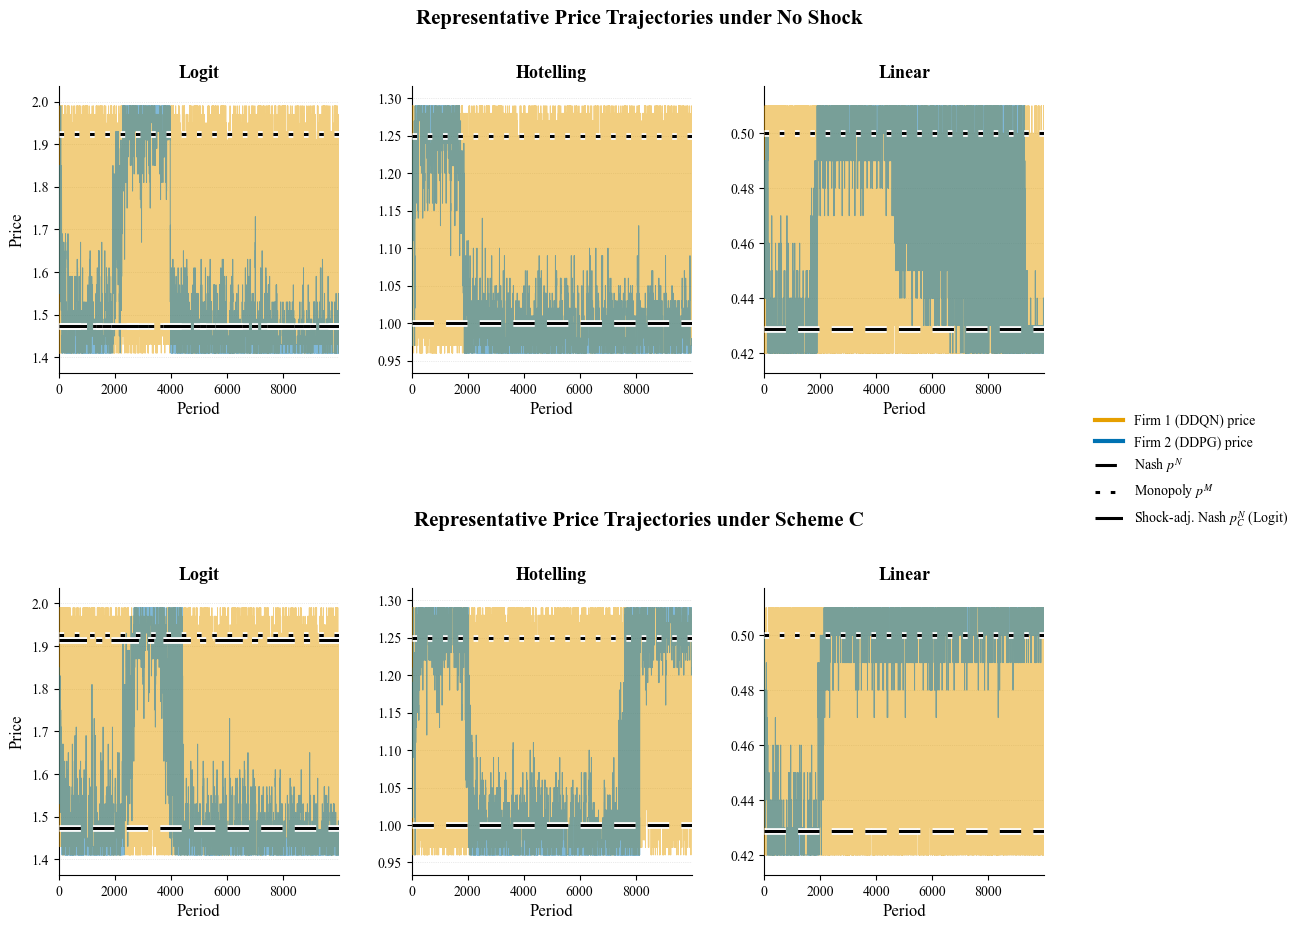

In [29]:
# ----------------------------------------------------------------------
# INPUT 1: representative-run CSVs, per shock regime
#   (same path pattern as before; one chosen run per market, per regime)
# ----------------------------------------------------------------------
chosen = {
    "None": chosen_none,   # <-- fill no-shock run ids
    "C":    chosen_c,   # <-- fill Scheme-C run ids
}
def traj_csv(regime, market):
    return f"./shock_{regime.lower()}/run_{chosen[regime][market.lower()]}/{market.lower()}.csv"

PRICE_COL_1, PRICE_COL_2 = "firm1_price", "firm2_price"   # rename if headers differ

# ----------------------------------------------------------------------
# INPUT 2: benchmarks per (regime, market).
#   Nash (pN), Monopoly (pM); Logit also gets shock-adjusted Nash (pN_C),
#   which DIFFERS between regimes -> set each row's value explicitly.
#   If a panel should show no shock-adj line, simply omit "pN_C".
# ----------------------------------------------------------------------
BENCH = {
    "None": {
        "Logit":     {"pN": 1.473, "pM": 1.925, "pN_C": 1.473},  # <-- no-shock shock-adj Nash
        "Hotelling": {"pN": 1.000, "pM": 1.250},
        "Linear":    {"pN": 0.4286,"pM": 0.500},
    },
    "C": {
        "Logit":     {"pN": 1.473, "pM": 1.925, "pN_C": 1.9151},  # <-- Scheme-C shock-adj Nash
        "Hotelling": {"pN": 1.000, "pM": 1.250},
        "Linear":    {"pN": 0.4286,"pM": 0.500},
    },
}

REGIMES = [("None", "No Shock"), ("C", "Scheme C")]   # top, bottom
MARKETS = ["Logit", "Hotelling", "Linear"]

# ---- colours: two distinct, colour-blind-safe hues whose overlap is a third tone ----
C1 = "#E69F00"      # Firm 1 (DDQN)  – orange
C2 = "#0072B2"      # Firm 2 (DDPG)  – blue  (overlap with orange -> teal-green)
# C2 = "#D81B8C"    # <-- swap to magenta to match Figs 2-7 (overlap then reads reddish)
TRAJ_ALPHA = 0.50   # < 1 so neither line occludes the other; overlaps blend

# ---- benchmark line styling: thick, black, white halo, distinct dashes ----
BENCH_KW = dict(color="black", lw=2.2, zorder=6, solid_capstyle="butt")
DASH_N   = (0, (7, 4))          # Nash            – long dash
DASH_M   = (0, (1.5, 3.5))      # Monopoly        – dotted
DASH_NC  = (0, (9, 3, 2, 3))    # Shock-adj Nash  – dash-dot
HALO     = [pe.Stroke(linewidth=4.8, foreground="white"), pe.Normal()]

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "axes.linewidth": 0.8,
})

fig = plt.figure(figsize=(13.5, 9.5))
subfigs = fig.subfigures(2, 1, hspace=0.12)   # requires matplotlib >= 3.4

for subfig, (regime, regime_label) in zip(subfigs, REGIMES):
    axes = subfig.subplots(1, 3)
    subfig.subplots_adjust(left=0.07, right=0.80, bottom=0.16, top=0.80, wspace=0.26)
    subfig.suptitle(f"Representative Price Trajectories under {regime_label}", fontweight="bold", fontsize=15, y=0.97)

    for ax, market in zip(axes, MARKETS):
        df = pd.read_csv(traj_csv(regime, market))
        t = np.arange(len(df))
        # alpha blending -> single-firm regions show their own hue,
        # overlapping regions show a blended (third) colour
        ax.plot(t, df[PRICE_COL_1], color=C1, lw=0.7, alpha=TRAJ_ALPHA,
                zorder=3, solid_capstyle="butt")
        ax.plot(t, df[PRICE_COL_2], color=C2, lw=0.7, alpha=TRAJ_ALPHA,
                zorder=4, solid_capstyle="butt")

        b = BENCH[regime][market]
        ax.axhline(b["pN"], ls=DASH_N, **BENCH_KW).set_path_effects(HALO)
        ax.axhline(b["pM"], ls=DASH_M, **BENCH_KW).set_path_effects(HALO)
        if "pN_C" in b:
            ax.axhline(b["pN_C"], ls=DASH_NC, **BENCH_KW).set_path_effects(HALO)

        ax.set_title(market, fontweight="bold")
        ax.set_xlabel("Period")
        ax.grid(True, axis="y", ls=":", lw=0.5, alpha=0.5, zorder=0)
        ax.spines[["top", "right"]].set_visible(False)
        ax.margins(x=0.0, y=0.08)
    axes[0].set_ylabel("Price")

# ---- shared legend (right strip reserved by right=0.80 above) ----
handles = [
    Line2D([], [], color=C1, lw=3,                 label="Firm 1 (DDQN) price"),
    Line2D([], [], color=C2, lw=3,                 label="Firm 2 (DDPG) price"),
    Line2D([], [], color="black", lw=2.2, ls=DASH_N,  label=r"Nash $p^{N}$"),
    Line2D([], [], color="black", lw=2.2, ls=DASH_M,  label=r"Monopoly $p^{M}$"),
    Line2D([], [], color="black", lw=2.2, ls=DASH_NC, label=r"Shock-adj. Nash $p^{N}_{C}$ (Logit)"),
]
fig.legend(handles=handles, loc="center right", bbox_to_anchor=(0.99, 0.5),
           frameon=False, fontsize=10)
fig.savefig("figure6_trajectories.png", dpi=300, bbox_inches="tight")
fig.savefig("figure6_trajectories.pdf", bbox_inches="tight")
plt.show()

# Graph 2

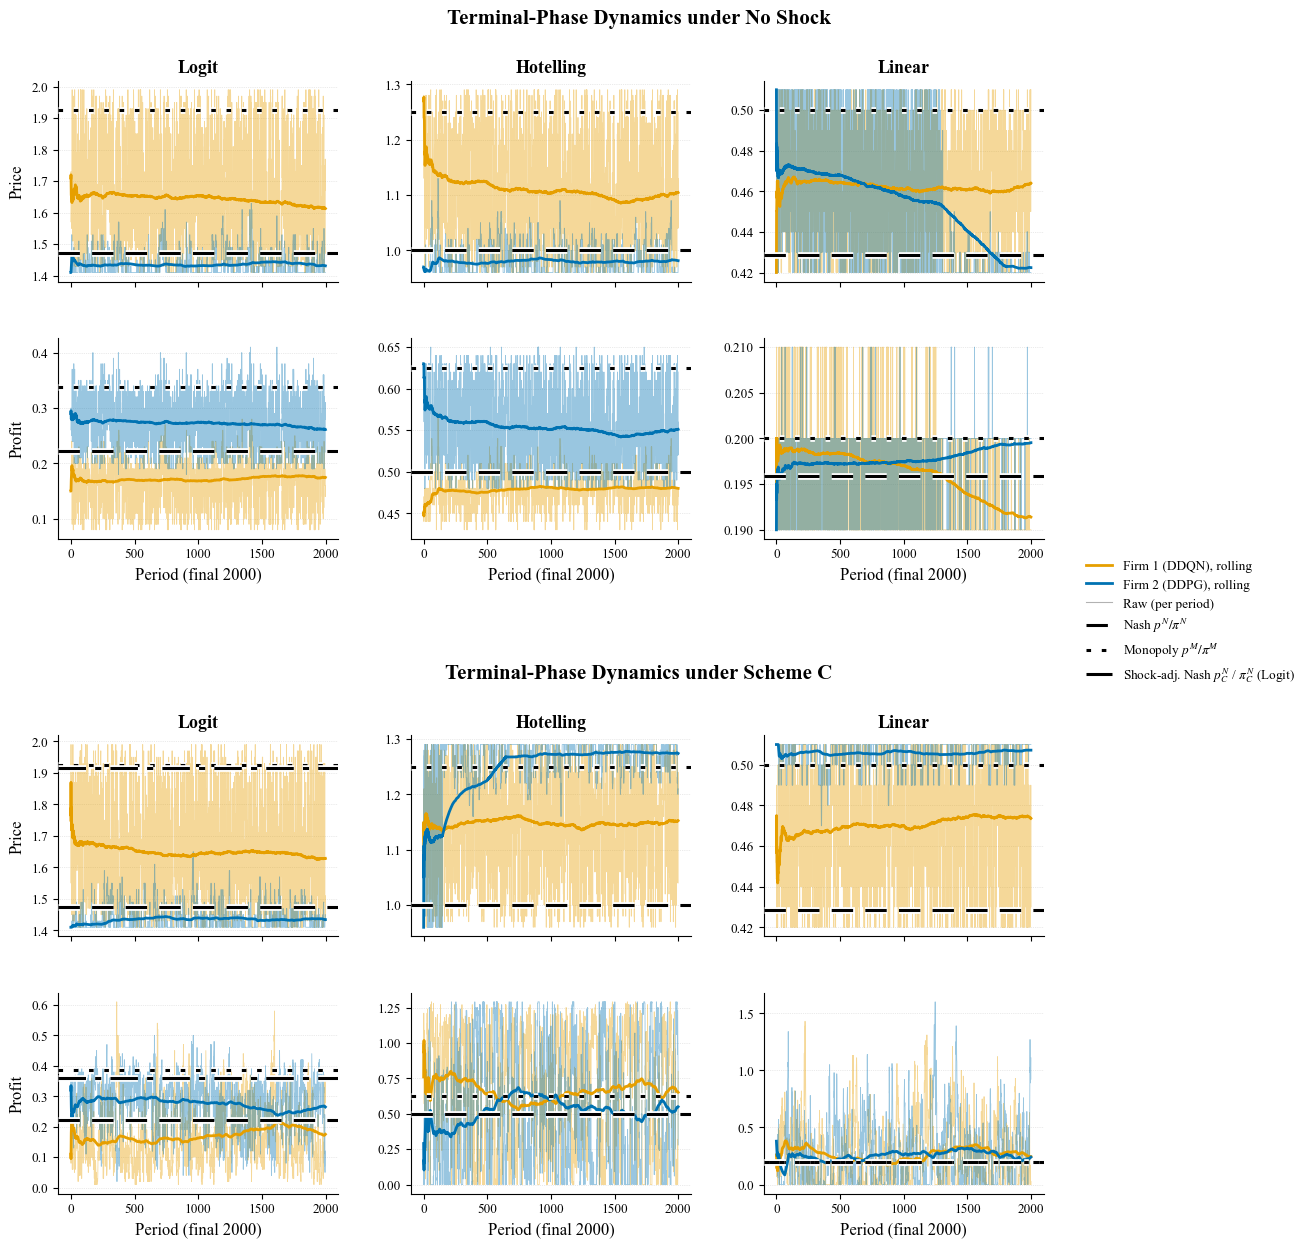

In [28]:
# ----------------------------------------------------------------------
# INPUT 1: representative-run CSVs, per shock regime (same path pattern)
# ----------------------------------------------------------------------
chosen = {
    "None": chosen_none,   # <-- fill no-shock run ids
    "C":    chosen_c,   # <-- fill Scheme-C run ids
}
def run_csv(regime, market):
    return f"./shock_{regime.lower()}/run_{chosen[regime][market.lower()]}/{market.lower()}.csv"

PCOL = {"p1":"firm1_price", "p2":"firm2_price",
        "pi1":"firm1_profit", "pi2":"firm2_profit"}

WINDOW = 500     # rolling window (periods)
TAIL   = 2000    # final periods to display

# ----------------------------------------------------------------------
# INPUT 2: PRICE and PROFIT benchmarks per (regime, market).
#   pN/pM = Nash/Monopoly price ; piN/piM = Nash/Monopoly profit.
#   Scheme-C Logit may carry shock-adjusted values.
# ----------------------------------------------------------------------
PRICE_BENCH = {
    "None": {
        "Logit":     {"pN":1.473, "pM":1.925},
        "Hotelling": {"pN":1.000, "pM":1.250},
        "Linear":    {"pN":0.4286,"pM":0.500},
    },
    "C": {
        "Logit":     {"pN":1.473, "pM":1.925, "pN_C":1.9151},  # delete "pN_C" to drop dash-dot
        "Hotelling": {"pN":1.000, "pM":1.250},
        "Linear":    {"pN":0.4286,"pM":0.500},
    },
}
PROFIT_BENCH = {
    "None": {
        "Logit":     {"piN":0.223, "piM":0.3375},
        "Hotelling": {"piN":0.500,  "piM":0.625},
        "Linear":    {"piN":0.1959, "piM":0.200},
    },
    "C": {
        "Logit":     {"piN":0.223, "piM":0.3855, "piN_C":0.3596},  # <-- set to shock-adjusted Logit profit benchmarks
        "Hotelling": {"piN":0.500,  "piM":0.625},
        "Linear":    {"piN":0.1959, "piM":0.200},
    },
}

REGIMES = [("None","No Shock"), ("C","Scheme C")]   # top block, bottom block
MARKETS = ["Logit","Hotelling","Linear"]

# ---- colours: distinct, colour-blind-safe; overlap of raw bands reads as a third tone ----
C1 = "#E69F00"     # Firm 1 (DDQN)  – orange
C2 = "#0072B2"     # Firm 2 (DDPG)  – blue  (swap to "#D81B8C" for magenta)
RAW_ALPHA = 0.40
ROLL_LW   = 2.0

# ---- reference lines: thick black, white halo, distinct dashes (shared by price & profit) ----
BENCH_KW = dict(color="black", lw=2.2, zorder=6, solid_capstyle="butt")
DASH_N   = (0, (7, 4))          # Nash      – long dash
DASH_M   = (0, (1.5, 3.5))      # Monopoly  – dotted
DASH_NC  = (0, (9, 3, 2, 3))    # Shock-adj Nash – dash-dot
HALO     = [pe.Stroke(linewidth=4.8, foreground="white"), pe.Normal()]

def hline(ax, y, dash):
    ax.axhline(y, ls=dash, **BENCH_KW).set_path_effects(HALO)

plt.rcParams.update({
    "font.family":"serif","font.serif":["Times New Roman","Times","DejaVu Serif"],
    "mathtext.fontset":"stix","font.size":11,"axes.titlesize":13,"axes.labelsize":12,
    "xtick.labelsize":9.5,"ytick.labelsize":9.5,"axes.linewidth":0.8,
})
def roll(s): return pd.Series(s).rolling(WINDOW, min_periods=1).mean().values

fig = plt.figure(figsize=(13.5, 12.5))
subfigs = fig.subfigures(2, 1, hspace=0.10)   # requires matplotlib >= 3.4

for subfig, (regime, regime_label) in zip(subfigs, REGIMES):
    axes = subfig.subplots(2, 3, sharex="col")     # row 0 = price, row 1 = profit
    subfig.subplots_adjust(left=0.07, right=0.80, bottom=0.09, top=0.86,
                           wspace=0.26, hspace=0.28)
    subfig.suptitle(f"Terminal-Phase Dynamics under {regime_label}", fontweight="bold", fontsize=15, y=0.98)

    for j, market in enumerate(MARKETS):
        df = pd.read_csv(run_csv(regime, market)).tail(TAIL).reset_index(drop=True)
        t  = np.arange(len(df))

        # --- price (top) ---
        axp = axes[0, j]
        for col, c in [(PCOL["p1"], C1), (PCOL["p2"], C2)]:
            axp.plot(t, df[col],       color=c, lw=0.6, alpha=RAW_ALPHA, zorder=2)
            axp.plot(t, roll(df[col]), color=c, lw=ROLL_LW,             zorder=4)
        pb = PRICE_BENCH[regime][market]
        hline(axp, pb["pN"], DASH_N)
        hline(axp, pb["pM"], DASH_M)
        if "pN_C" in pb:
            hline(axp, pb["pN_C"], DASH_NC)
        axp.set_title(market, fontweight="bold")
        axp.grid(True, axis="y", ls=":", lw=0.5, alpha=0.5, zorder=0)
        axp.spines[["top","right"]].set_visible(False)

        # --- profit (bottom) ---
        axq = axes[1, j]
        for col, c in [(PCOL["pi1"], C1), (PCOL["pi2"], C2)]:
            axq.plot(t, df[col],       color=c, lw=0.6, alpha=RAW_ALPHA, zorder=2)
            axq.plot(t, roll(df[col]), color=c, lw=ROLL_LW,             zorder=4)
        qb = PROFIT_BENCH[regime][market]
        
        if "piN_C" in qb and regime == "C":
            hline(axq, qb["piN_C"], DASH_NC)
            
        hline(axq, qb["piN"], DASH_N)
        hline(axq, qb["piM"], DASH_M)
        axq.set_xlabel(f"Period (final {TAIL})")
        axq.grid(True, axis="y", ls=":", lw=0.5, alpha=0.5, zorder=0)
        axq.spines[["top","right"]].set_visible(False)

    axes[0, 0].set_ylabel("Price")
    axes[1, 0].set_ylabel("Profit")

# ---- single shared legend (reference markers written once for the whole figure) ----
handles = [
    Line2D([],[],color=C1,lw=ROLL_LW, label="Firm 1 (DDQN), rolling"),
    Line2D([],[],color=C2,lw=ROLL_LW, label="Firm 2 (DDPG), rolling"),
    Line2D([],[],color="0.5",lw=0.8,alpha=0.6, label="Raw (per period)"),
    Line2D([],[],color="black",lw=2.2,ls=DASH_N,  label=r"Nash $p^{N}/\pi^{N}$"),
    Line2D([],[],color="black",lw=2.2,ls=DASH_M,  label=r"Monopoly $p^{M}/\pi^{M}$"),
    Line2D([],[],color="black",lw=2.2,ls=DASH_NC, label=r"Shock-adj. Nash $p^{N}_{C}$ / $\pi^{N}_{C}$ (Logit)"),
]
fig.legend(handles=handles, loc="center right", bbox_to_anchor=(0.995, 0.5),
           frameon=False, fontsize=9.5)

fig.savefig("figure7_rolling.png", dpi=300, bbox_inches="tight")
fig.savefig("figure7_rolling.pdf", bbox_inches="tight")
plt.show()